# Bridge detection — stage 1: can real build costs show a failed bridge?

**Who this is for.** This notebook is written to be readable without a technical
background. Every term of art gets a short explanation, in parentheses, at its
first use.

**The setting.** Our study asks what it costs to buy a national target for new
nuclear power plants. We use ReEDS (a computer model of the United States
electric power system, built by the National Renewable Energy Laboratory). In
the model, a rule forces the target plants to be built. We call this rule the
mandate. The model reports a price for this rule: the shadow price (the extra
payment, per unit of plant capacity per year, that is exactly enough to make
the target plants worth building). We read the shadow price as the required
subsidy (the government payment). Our data files call the same quantity the
"dual", which is the optimization term for it.

**The bridge.** In cheap futures, plants get cheaper as more of them are built.
The required subsidy then falls over time, and it can end. The subsidy works as
a bridge: it carries the industry until costs come down. In expensive futures,
costs do not come down, and the subsidy does not fall by 2050. We say: the
bridge fails.

**The question (Lincoln, 2026-08-20, ratified `[TODO]`).** Suppose the true
future is bad: the bridge will fail. How soon can a decision-maker know this
from the costs of real, completed plants? And what does the waiting cost? This
notebook answers only the stage-1 question: **can we make a claim here that
stands up?** Stage 2 (the actual estimate: the detection year, plus the subsidy
paid up to that year) runs only if stage 1 passes. The pass/fail rules were
fixed before the run; they are in `status.md` next to this notebook.

**What we have to work with.**

- 10,000 simulated cost futures (a Monte Carlo ensemble: the computer draws
  10,000 random but plausible combinations of the uncertain cost drivers, and
  computes each one's cost path to 2050). We call each future a world.
- For 37 worlds, we also ran the full power-system model. For these we know the
  subsidy path, so we know whether the subsidy decays (falls below half of its
  peak by 2050). These 37 are the anchor cases.
- For the other worlds, we know only the cost paths.

**The two moves.**

1. **B1 (the gate).** Build a stand-in label (a proxy) for "the subsidy does
   not decay", computed from a world's cost path alone. Test it against the 37
   anchors, where the subsidy truth is known.
2. **B2–B4.** Apply the validated stand-in to all 10,000 worlds. Then ask: how
   early does the start of a cost path show the class of its end?

This is not a circular argument. The label describes the end of a path (the
2050 state). The observation is the start of the path (costs through some year
T). B1 ties the label to the subsidy truth. B3 and B4 then measure how early
the observed costs carry that information.

**Data rules.** All subsidy numbers come from stored and checked model outputs.
Nothing is recomputed from raw model files. The cost signal is the overnight
capital cost, OCC (the cost to build a plant, stated as if it were built
overnight, so with no interest during construction; measured in 2022 dollars
per kilowatt of capacity). The build cost including financing is carried as a
backup indicator. The study covers SMRs (small modular reactors: factory-built
reactors of about 300 megawatts each) under six published deployment targets,
here called schedules, from smallest to largest: eia, aj, iaea, mck, cop28, eo
(from the US Energy Information Administration; the Abou-Jaoude study; the
International Atomic Energy Agency; McKinsey; the COP28 pledge; the 2025
Executive Order). Large-reactor anchors serve as a side check only; the verdict
rests on the SMR family.

Run on the **playground-env** kernel. Tables are named `b##`, figures `d##`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys
sys.path.insert(0, str(Path.cwd().parent))
import plotstyle as ps
ps.apply()

pd.set_option("display.width", 200)

HERE = Path.cwd()
assert HERE.name == "bridge_detection", f"run from z-ethan/bridge_detection/, not {HERE}"
REPO = HERE.parents[1]
EXPORTS = HERE / "exports"
FIGURES = HERE / "figures"
EXPORTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

MC_EXPORTS = REPO / "z-ethan" / "mc" / "exports"
CHECKS3 = REPO / "z-ethan" / "step3_checks" / "exports"
CHECKS4 = REPO / "z-ethan" / "step4_checks" / "exports"
S3ANALYSIS = REPO / "z-ethan" / "step3_analysis" / "exports"

# ---- the MC ensemble --------------------------------------------------------------
Z = np.load(MC_EXPORTS / "mc_perdraw.npz")
META = json.loads(str(Z["meta_json"]))
assert META["n_draws"] == 10000 and META["master_seed"] == 20260715, META
YEARS = Z["years"]
assert YEARS[0] == 2024 and YEARS[-1] == 2050, YEARS
YI = {int(y): i for i, y in enumerate(YEARS)}
OBS_YEARS = list(range(2031, 2051))  # first mandated build year is 2031

# schedule naming: full name (selection CSVs) <-> npz token <-> case abbrev
SCHEDULES = ["eia", "aj", "iaea", "mck", "cop28", "eo"]  # ambition order
AB2TOK = {"eia": "eia_aeo_high", "aj": "abou_jaoude", "iaea": "iaea_high",
          "mck": "mckinsey", "cop28": "cop28", "eo": "eo2025"}
TOK2AB = {v: k for k, v in AB2TOK.items()}
NAME2AB = {str(n): TOK2AB[str(t)] for n, t in zip(Z["sched_order"], Z["scen_tokens"])}
assert set(NAME2AB.values()) == set(SCHEDULES), NAME2AB
WORLD_COLS = [str(c) for c in Z["world_columns"]]

# ---- the realized anchors ---------------------------------------------------------
t04 = pd.read_csv(S3ANALYSIS / "t04_bridge_metrics.csv")
assert len(t04) == 37, len(t04)
t04 = t04[t04["case"] != "smr100_eia_p50_eq"].set_index("case")

def decay_class(row):
    # verbatim step4_analysis R2 classifier: first_year_below_half_peak already
    # includes the zero-dual-after-peak arm of the t04 definition
    if pd.notna(row["first_year_below_half_peak"]):
        return "decays"
    return "flat" if row["end_over_peak"] >= 0.95 else "declines"

t04["cls"] = t04.apply(decay_class, axis=1)
t04["bad"] = t04["cls"] != "decays"   # bad = the bridge does not decay

# draw registries: case -> draw_index into the 10000-row npz arrays
def load_registry(path):
    df = pd.read_csv(path)
    df["ab"] = df["schedule"].map(NAME2AB)
    assert df["ab"].notna().all(), df["schedule"].unique()
    return df

reg_smr = load_registry(MC_EXPORTS / "smr100" / "selected_draws.csv")
assert len(reg_smr) == 18, len(reg_smr)
reg_lrg = pd.concat([load_registry(MC_EXPORTS / "smr100" / "selected_draws_large.csv"),
                     load_registry(MC_EXPORTS / "step4" / "selected_draws_large.csv")])
reg_lrg = reg_lrg.drop_duplicates(subset=["ab", "percentile"])
assert len(reg_lrg) == 18, len(reg_lrg)

# canonical dual trajectories (context figure + freshness check only)
duals3 = pd.read_csv(CHECKS3 / "duals_by_year.csv")
smr_cases = [f"smr100_{ab}_{p}" for ab in SCHEDULES for p in ["p05", "p50", "p95"]]
assert set(smr_cases) <= set(duals3["case"].unique())

print(f"ensemble: {META['n_draws']} draws, years {YEARS[0]}-{YEARS[-1]}")
print(f"anchors: {len(t04)} cases; smr classes:")
print(t04.loc[[c for c in smr_cases]]["cls"].value_counts().to_string())


ensemble: 10000 draws, years 2024-2050
anchors: 36 cases; smr classes:
cls
decays      9
declines    9


## B1 — the gate: can a cost-based indicator reproduce the known subsidy classes?

We have 18 SMR anchor cases: 6 schedules times 3 cost levels. The cost levels
are named p05, p50, and p95 (the 5th, 50th, and 95th percentiles of the
ensemble: a cheap world that only 5% of worlds beat, the middle world, and an
expensive world that only 5% of worlds exceed). For each anchor we know the
truth from the subsidy path: bad = the subsidy does not decay.

We test four candidate indicators. Each is computed from the anchor's own cost
path. The sign rule is: a higher value means a worse world.

- the 2050 cost level (dollars per kilowatt in 2050);
- the 2050 cost level including financing;
- the decline ratio (the cost in 2050 divided by the cost in 2031, the first
  build year — a value near 1 means costs barely fell);
- the drawn learning rate, negated (the learning rate is the percentage cost
  drop each time the total built capacity doubles; it is an input of the
  simulation, not something an observer can see, so it is shown for diagnosis
  only and cannot be the detector).

For each indicator we report two things. First, the Spearman rank correlation
with the anchors' decay measure (a score between -1 and 1; a score of 1 means
the two orderings agree perfectly). Second, the best single cut-off: the value
that, used as a simple threshold, misclassifies the fewest of the 18 anchors.

The economics predicts that a *relative* indicator should win. At the middle
cost level, the class differs by schedule: three schedules decay and three do
not. A bigger program builds more, learns more, and travels further down its
cost curve. What matters is how far the cost has fallen, not where it started.

*A recorded quirk (side check only):* one large-reactor anchor gets the
"decays" label through a technical rule (years in which the subsidy is exactly
zero), not through a sustained cost fall. The large-reactor anchors are a
secondary check; the verdict does not rest on them.

In [2]:
def anchor_table(reg, tech):
    rows = []
    for _, r in reg.iterrows():
        case = f"{'smr100' if tech == 'smr' else 'large100'}_{r['ab']}_{r['percentile']}"
        d = int(r["draw_index"])
        occ = Z[f"occ_{AB2TOK[r['ab']]}_{tech}"][d]
        fin = Z[f"fincapex_{AB2TOK[r['ab']]}_{tech}"][d]
        w = Z[f"worlds_{AB2TOK[r['ab']]}"][d]
        lr = w[WORLD_COLS.index(f"lr_{tech}")]
        assert np.isclose(lr, r[f"lr_{tech}"], rtol=1e-9), (case, lr, r[f"lr_{tech}"])
        rows.append(dict(case=case, ab=r["ab"], pct=r["percentile"], draw=d,
                         occ2031=occ[YI[2031]], occ2050=occ[YI[2050]],
                         ratio_2050_2031=occ[YI[2050]] / occ[YI[2031]],
                         fincapex2050=fin[YI[2050]], neg_lr=-lr))
    df = pd.DataFrame(rows).set_index("case")
    df = df.join(t04[["end_over_peak", "cls", "bad"]])
    assert df["cls"].notna().all(), df.index[df["cls"].isna()]
    return df

A_SMR = anchor_table(reg_smr, "smr")
A_LRG = anchor_table(reg_lrg, "large")

FEATURES = ["occ2050", "fincapex2050", "ratio_2050_2031", "neg_lr"]
OBSERVABLE = ["occ2050", "fincapex2050", "ratio_2050_2031"]

def best_threshold(x, bad):
    xs = np.sort(np.unique(x))
    best = (np.nan, len(bad) + 1)
    for th in (xs[1:] + xs[:-1]) / 2:
        err = int(((x > th) != bad).sum())
        if err < best[1]:
            best = (float(th), err)
    return best

def evaluate(df, label):
    out = []
    for f in FEATURES:
        rho = df[f].corr(df["end_over_peak"], method="spearman")
        th, err = best_threshold(df[f].values, df["bad"].values)
        out.append(dict(anchors=label, feature=f, spearman_vs_end_over_peak=round(rho, 3),
                        threshold=th, errors_of_18=err,
                        observable=f in OBSERVABLE))
    return pd.DataFrame(out)

b01_eval = pd.concat([evaluate(A_SMR, "smr"), evaluate(A_LRG, "large")], ignore_index=True)

# winner: observable feature with fewest smr errors (tie -> listed order)
smr_obs = b01_eval[(b01_eval["anchors"] == "smr") & b01_eval["observable"]]
win = smr_obs.sort_values(["errors_of_18"], kind="stable").iloc[0]
WINNER, THETA, ERR_SMR = win["feature"], float(win["threshold"]), int(win["errors_of_18"])

A_SMR["pred_bad"] = A_SMR[WINNER] > THETA
conf = pd.crosstab(A_SMR["bad"], A_SMR["pred_bad"], rownames=["bad (dual)"],
                   colnames=["pred bad (cost)"])
misses = A_SMR[A_SMR["pred_bad"] != A_SMR["bad"]]

b01 = A_SMR.reset_index().assign(anchors="smr")
b01.to_csv(EXPORTS / "b01_anchor_validation.csv", index=False)
b01_eval.to_csv(EXPORTS / "b01_feature_eval.csv", index=False)

print(b01_eval.to_string(index=False))
print(f"\nwinner (smr, observable): {WINNER}, threshold {THETA:.0f}, "
      f"errors {ERR_SMR}/18")
print("\nconfusion (smr anchors):")
print(conf.to_string())
if len(misses):
    print("\nmisclassified anchors:")
    print(misses[[WINNER, "end_over_peak", "cls", "bad", "pred_bad"]].to_string())


anchors         feature  spearman_vs_end_over_peak   threshold  errors_of_18  observable
    smr         occ2050                      0.901 3996.106645             1        True
    smr    fincapex2050                      0.901 5290.883473             1        True
    smr ratio_2050_2031                      0.888    0.581346             0        True
    smr          neg_lr                      0.799   -0.096410             1       False
  large         occ2050                      0.845 3561.108538             1        True
  large    fincapex2050                      0.804 4561.699085             2        True
  large ratio_2050_2031                      0.919    0.638378             1        True
  large          neg_lr                      0.633   -0.107400             3       False

winner (smr, observable): ratio_2050_2031, threshold 1, errors 0/18

confusion (smr anchors):
pred bad (cost)  False  True 
bad (dual)                   
False                9      0
True          

saved -> figures\d01_dual_paths_by_class.png


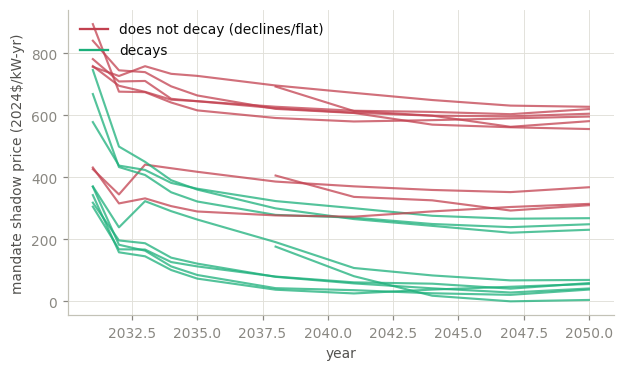

In [3]:
# ---- d01: what the detector is trying to recover -------------------------------
# realized smr dual trajectories, colored by the dual-side class (good = decays)
fig, ax = plt.subplots(figsize=(ps.W1, 3.6))
KWYR = 1e-3
for case in smr_cases:
    d = duals3[(duals3["case"] == case) & (duals3["t"] >= 2028)
               & (duals3["mandate_MW"] > 0)]
    bad = bool(t04.loc[case, "bad"])
    ax.plot(d["t"], d["dual_2024_MWyr"] * KWYR,
            color=ps.ACCENT["red"] if bad else ps.ACCENT["green"],
            alpha=0.75, lw=1.4)
ax.plot([], [], color=ps.ACCENT["red"], label="does not decay (declines/flat)")
ax.plot([], [], color=ps.ACCENT["green"], label="decays")
ax.set_xlabel("year")
ax.set_ylabel(f"mandate shadow price {ps.usd('kW-yr', 2024)}")
ax.legend(loc="upper left")
ps.savefig(fig, FIGURES / "d01_dual_paths_by_class.png")
plt.show()


## B2 — label all 10,000 worlds

We now apply the winning indicator and its cut-off to every world, separately
for each schedule. Each world gets a label: bad (the subsidy would not decay)
or good. B1 bounds how often this label is wrong. Two checks must hold. First,
the three anchor worlds in each schedule must get the same label that the B1
test gave them. Second, the share of bad worlds must fall as the schedule gets
bigger, because bigger programs learn more.

In [4]:
def draw_feature(ab, tech="smr"):
    occ = Z[f"occ_{AB2TOK[ab]}_{tech}"]
    fin = Z[f"fincapex_{AB2TOK[ab]}_{tech}"]
    feats = {"occ2050": occ[:, YI[2050]],
             "fincapex2050": fin[:, YI[2050]],
             "ratio_2050_2031": occ[:, YI[2050]] / occ[:, YI[2031]]}
    return feats[WINNER]

BAD = {ab: draw_feature(ab) > THETA for ab in SCHEDULES}

rows = []
for ab in SCHEDULES:
    anchors = A_SMR[A_SMR["ab"] == ab]
    agree = all(BAD[ab][int(r["draw"])] == r["pred_bad"] for _, r in anchors.iterrows())
    rows.append(dict(schedule=ab, share_bad=round(float(BAD[ab].mean()), 4),
                     n_bad=int(BAD[ab].sum()), anchor_draws_consistent=agree))
b02 = pd.DataFrame(rows)
assert b02["anchor_draws_consistent"].all()
b02.to_csv(EXPORTS / "b02_class_shares.csv", index=False)
print(b02.to_string(index=False))


schedule  share_bad  n_bad  anchor_draws_consistent
     eia     0.8832   8832                     True
      aj     0.7251   7251                     True
    iaea     0.5199   5199                     True
     mck     0.4620   4620                     True
   cop28     0.3479   3479                     True
      eo     0.2835   2835                     True


## B3 — how early do bad and good worlds separate?

For each observation year T, we give every world a score that an observer could
compute in year T. Then we ask how well that score separates bad worlds from
good ones. The separation measure is the AUC (a score from 0.5 to 1.0: the
probability that a randomly chosen bad world scores higher than a randomly
chosen good one; 0.5 is a coin flip, 1.0 is perfect separation).

The primary score is the decline to date: the cost in year T divided by the
cost in 2031. This matches the validated label from B1, and an observer can
compute it from completed plants. The raw cost level in year T is kept as a
comparison column. The level was our first attempt, and it fails for the small
schedules: the label is about *relative* decline, and starting cost levels
differ across worlds. That is a lesson about matching the indicator to the
label. It is not evidence against separation.

One caution for reading the curve: the score must approach perfect separation
as T approaches 2050, because the label lives at the end of the same path. The
information is in **how early** the curve rises. The pass rule asks for an AUC
at or above 0.9 well before 2045.

first year AUC(decline to date) >= 0.9: {'eia': 2037, 'aj': 2032, 'iaea': 2032, 'mck': 2032, 'cop28': 2032, 'eo': 2032}
saved -> figures\d02_auc_by_year.png


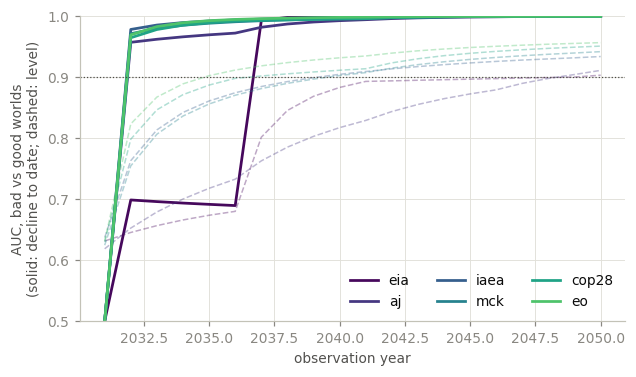

In [5]:
def auc(score, bad):
    r = pd.Series(score).rank().values
    nb_, ng = int(bad.sum()), int((~bad).sum())
    return (r[bad].sum() - nb_ * (nb_ + 1) / 2) / (nb_ * ng)

rows = []
for ab in SCHEDULES:
    occ = Z[f"occ_{AB2TOK[ab]}_smr"]
    base = occ[:, YI[2031]]
    for t in OBS_YEARS:
        rows.append(dict(
            schedule=ab, year=t,
            auc_decline_to_date=round(auc(occ[:, YI[t]] / base, BAD[ab]), 4),
            auc_level=round(auc(occ[:, YI[t]], BAD[ab]), 4)))
b03 = pd.DataFrame(rows)
CROSS = {}
for ab in SCHEDULES:
    hit = b03[(b03["schedule"] == ab) & (b03["auc_decline_to_date"] >= 0.9)]
    CROSS[ab] = int(hit["year"].min()) if len(hit) else None
b03.to_csv(EXPORTS / "b03_auc_by_year.csv", index=False)
print("first year AUC(decline to date) >= 0.9:", CROSS)

fig, ax = plt.subplots(figsize=(ps.W1, 3.6))
for ab in SCHEDULES:
    d = b03[b03["schedule"] == ab]
    ax.plot(d["year"], d["auc_decline_to_date"], color=ps.SCHED_C[ab],
            lw=1.8, label=ab)
    ax.plot(d["year"], d["auc_level"], color=ps.SCHED_C[ab],
            lw=1.0, ls="--", alpha=0.35)
ax.axhline(0.9, color=ps.BASE_C, lw=0.8, ls=":")
ax.set_xlabel("observation year")
ax.set_ylabel("AUC, bad vs good worlds\n(solid: decline to date; dashed: level)")
ax.set_ylim(0.5, 1.0)
ax.legend(ncols=3)
ps.savefig(fig, FIGURES / "d02_auc_by_year.png")
plt.show()


## B4 — the year-by-year observer (a preview of stage 2)

Here we simulate a careful observer who watches costs year by year.

The observer starts with the 10,000 worlds as the menu of possibilities, and
with the prior (the starting probability that the world is bad: simply the
share of bad worlds in the menu). Each year the observer sees the realized
cost. We keep only the worlds whose cost paths match everything seen so far,
within a tolerance band of plus or minus delta (an allowed error of 5%, 10%, or
20% around the observed cost). The band stands in for real-world measurement
noise: our simulated cost paths are smooth, so an observer with perfect vision
could identify the exact world at once, and that would overstate what is
knowable. The updated probability that the world is bad (the posterior) is the
share of bad worlds among the matching survivors.

Detection means: the posterior reaches 0.9. For each schedule and each band
width, over a fixed random sample of 300 truly bad worlds, we report the share
detected by 2050, the middle (median) detection year, and the number of
matching worlds at the moment of detection (the support — a thin support means
the conclusion rests on few look-alike worlds). We also run 300 truly good
worlds through the same rule and report the false-alarm rate (how often a good
world is wrongly declared bad).

In [6]:
rng = np.random.default_rng(20260820)
DELTAS = [0.05, 0.10, 0.20]
N_TRUE = 300

def detection_run(ab, delta, true_idx, bad):
    occ = Z[f"occ_{AB2TOK[ab]}_smr"]
    obs = occ[:, [YI[t] for t in OBS_YEARS]]
    det_year, det_n = [], []
    for w in true_idx:
        mask = np.ones(len(obs), dtype=bool)
        dy, dn = None, None
        for j, t in enumerate(OBS_YEARS):
            mask &= np.abs(obs[:, j] - obs[w, j]) <= delta * obs[w, j]
            post = bad[mask].mean()
            if post >= 0.9:
                dy, dn = t, int(mask.sum())
                break
        det_year.append(dy)
        det_n.append(dn)
    return det_year, det_n

rows = []
for ab in SCHEDULES:
    bad = BAD[ab]
    bad_idx = np.flatnonzero(bad)
    good_idx = np.flatnonzero(~bad)
    sub_bad = rng.choice(bad_idx, size=min(N_TRUE, len(bad_idx)), replace=False)
    sub_good = rng.choice(good_idx, size=min(N_TRUE, len(good_idx)), replace=False)
    for delta in DELTAS:
        dy, dn = detection_run(ab, delta, sub_bad, bad)
        got = [y for y in dy if y is not None]
        ns = [n for n in dn if n is not None]
        fa_dy, _ = detection_run(ab, delta, sub_good, bad)
        rows.append(dict(
            schedule=ab, delta=delta, n_true_bad=len(sub_bad),
            share_detected=round(len(got) / len(dy), 3),
            median_det_year=int(np.median(got)) if got else None,
            q25=int(np.percentile(got, 25)) if got else None,
            q75=int(np.percentile(got, 75)) if got else None,
            share_det_by_2040=round(np.mean([y is not None and y <= 2040 for y in dy]), 3),
            share_det_by_2045=round(np.mean([y is not None and y <= 2045 for y in dy]), 3),
            median_support_at_det=int(np.median(ns)) if ns else None,
            false_alarm_rate_good=round(np.mean([y is not None for y in fa_dy]), 3)))
        print(f"{ab} delta={delta}: {rows[-1]}")
b04 = pd.DataFrame(rows)
b04.to_csv(EXPORTS / "b04_detection_years.csv", index=False)


eia delta=0.05: {'schedule': 'eia', 'delta': 0.05, 'n_true_bad': 300, 'share_detected': 0.967, 'median_det_year': 2032, 'q25': 2031, 'q75': 2037, 'share_det_by_2040': 0.963, 'share_det_by_2045': 0.963, 'median_support_at_det': 1621, 'false_alarm_rate_good': 0.4}
eia delta=0.1: {'schedule': 'eia', 'delta': 0.1, 'n_true_bad': 300, 'share_detected': 0.923, 'median_det_year': 2032, 'q25': 2031, 'q75': 2037, 'share_det_by_2040': 0.917, 'share_det_by_2045': 0.923, 'median_support_at_det': 2854, 'false_alarm_rate_good': 0.35}


eia delta=0.2: {'schedule': 'eia', 'delta': 0.2, 'n_true_bad': 300, 'share_detected': 0.817, 'median_det_year': 2031, 'q25': 2031, 'q75': 2037, 'share_det_by_2040': 0.78, 'share_det_by_2045': 0.807, 'median_support_at_det': 5474, 'false_alarm_rate_good': 0.303}


aj delta=0.05: {'schedule': 'aj', 'delta': 0.05, 'n_true_bad': 300, 'share_detected': 0.92, 'median_det_year': 2036, 'q25': 2034, 'q75': 2037, 'share_det_by_2040': 0.79, 'share_det_by_2045': 0.88, 'median_support_at_det': 888, 'false_alarm_rate_good': 0.003}


aj delta=0.1: {'schedule': 'aj', 'delta': 0.1, 'n_true_bad': 300, 'share_detected': 0.83, 'median_det_year': 2038, 'q25': 2037, 'q75': 2041, 'share_det_by_2040': 0.62, 'share_det_by_2045': 0.777, 'median_support_at_det': 1952, 'false_alarm_rate_good': 0.0}


aj delta=0.2: {'schedule': 'aj', 'delta': 0.2, 'n_true_bad': 300, 'share_detected': 0.617, 'median_det_year': 2043, 'q25': 2040, 'q75': 2047, 'share_det_by_2040': 0.177, 'share_det_by_2045': 0.41, 'median_support_at_det': 3962, 'false_alarm_rate_good': 0.0}
iaea delta=0.05: {'schedule': 'iaea', 'delta': 0.05, 'n_true_bad': 300, 'share_detected': 0.887, 'median_det_year': 2033, 'q25': 2032, 'q75': 2035, 'share_det_by_2040': 0.82, 'share_det_by_2045': 0.86, 'median_support_at_det': 534, 'false_alarm_rate_good': 0.007}


...

mck delta=0.2: {'schedule': 'mck', 'delta': 0.2, 'n_true_bad': 300, 'share_detected': 0.407, 'median_det_year': 2041, 'q25': 2037, 'q75': 2044, 'share_det_by_2040': 0.193, 'share_det_by_2045': 0.34, 'median_support_at_det': 2677, 'false_alarm_rate_good': 0.0}
cop28 delta=0.05: {'schedule': 'cop28', 'delta': 0.05, 'n_true_bad': 300, 'share_detected': 0.877, 'median_det_year': 2033, 'q25': 2033, 'q75': 2035, 'share_det_by_2040': 0.793, 'share_det_by_2045': 0.857, 'median_support_at_det': 342, 'false_alarm_rate_good': 0.0}


cop28 delta=0.1: {'schedule': 'cop28', 'delta': 0.1, 'n_true_bad': 300, 'share_detected': 0.733, 'median_det_year': 2036, 'q25': 2034, 'q75': 2042, 'share_det_by_2040': 0.53, 'share_det_by_2045': 0.673, 'median_support_at_det': 954, 'false_alarm_rate_good': 0.0}


cop28 delta=0.2: {'schedule': 'cop28', 'delta': 0.2, 'n_true_bad': 300, 'share_detected': 0.41, 'median_det_year': 2043, 'q25': 2037, 'q75': 2046, 'share_det_by_2040': 0.137, 'share_det_by_2045': 0.293, 'median_support_at_det': 2012, 'false_alarm_rate_good': 0.0}
eo delta=0.05: {'schedule': 'eo', 'delta': 0.05, 'n_true_bad': 300, 'share_detected': 0.817, 'median_det_year': 2033, 'q25': 2033, 'q75': 2035, 'share_det_by_2040': 0.74, 'share_det_by_2045': 0.797, 'median_support_at_det': 277, 'false_alarm_rate_good': 0.0}


eo delta=0.1: {'schedule': 'eo', 'delta': 0.1, 'n_true_bad': 300, 'share_detected': 0.65, 'median_det_year': 2036, 'q25': 2034, 'q75': 2038, 'share_det_by_2040': 0.53, 'share_det_by_2045': 0.617, 'median_support_at_det': 761, 'false_alarm_rate_good': 0.0}


eo delta=0.2: {'schedule': 'eo', 'delta': 0.2, 'n_true_bad': 300, 'share_detected': 0.323, 'median_det_year': 2042, 'q25': 2037, 'q75': 2047, 'share_det_by_2040': 0.14, 'share_det_by_2045': 0.213, 'median_support_at_det': 1684, 'false_alarm_rate_good': 0.0}


saved -> figures\d03_detection_year_ecdf.png


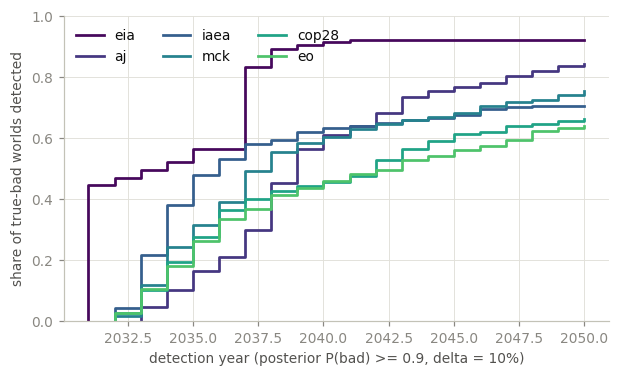

In [7]:
# ---- d03: detection-year ECDF at delta = 0.10 ----------------------------------
fig, ax = plt.subplots(figsize=(ps.W1, 3.6))
for ab in SCHEDULES:
    bad = BAD[ab]
    bad_idx = np.flatnonzero(bad)
    sub = np.random.default_rng(20260820).choice(
        bad_idx, size=min(N_TRUE, len(bad_idx)), replace=False)
    dy, _ = detection_run(ab, 0.10, sub, bad)
    got = np.sort([y for y in dy if y is not None])
    if len(got):
        ecdf_x = np.concatenate([got, [2050]])
        ecdf_y = np.concatenate([np.arange(1, len(got) + 1), [len(got)]]) / len(dy)
        ax.step(ecdf_x, ecdf_y, where="post", color=ps.SCHED_C[ab], lw=1.8, label=ab)
ax.set_xlabel("detection year (posterior P(bad) >= 0.9, delta = 10%)")
ax.set_ylabel("share of true-bad worlds detected")
ax.set_ylim(0, 1)
ax.legend(ncols=3, loc="upper left")
ps.savefig(fig, FIGURES / "d03_detection_year_ecdf.png")
plt.show()


## B5 — verdict and caveats

**Why the frozen build path is not a problem (the "myopia" point).** The
power-system model plans one step at a time, without foresight (the technical
term is a myopic solve), and the mandate fixes the build path. So a world's
cost path is set by its random draw and its schedule. Nothing the observer
learns feeds back into what gets built. The exercise is therefore internally
valid on one condition: the mandate stays enforced. That condition is exactly
the policy setting of the question ("we committed; when do we know the bridge
failed?"). What the exercise cannot say is what a decision-maker should *do*
at detection. That is out of scope by our standing rule: this analysis
provides information, never a recommendation.

**Honesty about observation.** The simulated cost paths are smooth curves with
no plant-to-plant noise. B4's tolerance band stands in for that noise. The
tighter the band, the closer the observer is to perfect. Any detection year we
quote must therefore come from the loose-band (cautious) side, or be framed as
a best case: "even a perfect observer cannot know before year X." A single
quotable warning rule ("if the cost has not fallen below Y by year T, the world
is bad") is only defensible because B3 shows clean separation; stage 2 would
state such a rule with explicit error rates.

**The prior caveat (found in the first pass).** The detection rule "posterior
at or above 0.9" asks little of the data where the starting probability is
already high. For the smallest schedule (eia), the prior is about 0.88, so the
rule nearly fires on its own, and the false-alarm rate shows it (30–40% for
eia against roughly 0–1% elsewhere). Stage 2 must use a rule that is adjusted
for the prior (for example a Bayes factor: a measure of how much the evidence
itself shifts the odds), and eia detection years are not quotable under the
current rule.

**Verdict logic (rules fixed in `status.md` before the run):** PASS = the
anchor gate holds (at most 2 misses of 18) AND every schedule's AUC crosses
0.9 by 2045 AND the median detection year at the 10% band lands by 2045 in
every schedule. PARTIAL = the anchor gate holds, and separation exists before
2050, but only under the tighter framings. FAIL = the anchor gate fails, or
separation arrives only at or after 2050.

In [8]:
gate1 = ERR_SMR <= 2
gate2 = all(y is not None and y <= 2045 for y in CROSS.values())
med10 = {r["schedule"]: r["median_det_year"]
         for _, r in b04[b04["delta"] == 0.10].iterrows()}
gate3 = all(y is not None and y <= 2045 for y in med10.values())

if gate1 and gate2 and gate3:
    verdict = "PASS"
elif gate1 and all(y is not None for y in CROSS.values()):
    verdict = "PARTIAL"
else:
    verdict = "FAIL"

b05 = pd.DataFrame([
    dict(metric="anchor_errors_smr_of_18", value=ERR_SMR),
    dict(metric="anchor_gate_max2", value=gate1),
    dict(metric="winner_feature", value=WINNER),
    dict(metric="winner_threshold", value=round(THETA, 4)),
    *[dict(metric=f"auc90_first_year_{ab}", value=CROSS[ab]) for ab in SCHEDULES],
    dict(metric="auc_gate_by2045", value=gate2),
    *[dict(metric=f"median_det_year_d10_{ab}", value=med10[ab]) for ab in SCHEDULES],
    dict(metric="detection_gate_by2045", value=gate3),
    dict(metric="verdict", value=verdict),
])
b05.to_csv(EXPORTS / "b05_verdict.csv", index=False)
print(b05.to_string(index=False))
print(f"\nSTAGE 1 VERDICT: {verdict}")


                   metric           value
  anchor_errors_smr_of_18               0
         anchor_gate_max2            True
           winner_feature ratio_2050_2031
         winner_threshold          0.5813
     auc90_first_year_eia            2037
      auc90_first_year_aj            2032
    auc90_first_year_iaea            2032
     auc90_first_year_mck            2032
   auc90_first_year_cop28            2032
      auc90_first_year_eo            2032
          auc_gate_by2045            True
  median_det_year_d10_eia            2032
   median_det_year_d10_aj            2038
 median_det_year_d10_iaea            2035
  median_det_year_d10_mck            2036
median_det_year_d10_cop28            2036
   median_det_year_d10_eo            2036
    detection_gate_by2045            True
                  verdict            PASS

STAGE 1 VERDICT: PASS


In [9]:
manifest = sorted(p.name for p in EXPORTS.glob("b0*.csv")) \
    + sorted(p.name for p in FIGURES.glob("d0*.png"))
print("outputs written by this notebook:")
for m_ in manifest:
    print(" ", m_)


outputs written by this notebook:
  b01_anchor_validation.csv
  b01_feature_eval.csv
  b02_class_shares.csv
  b03_auc_by_year.csv
  b04_detection_years.csv
  b05_verdict.csv
  d01_dual_paths_by_class.png
  d02_auc_by_year.png
  d03_detection_year_ecdf.png
